# 09 — Realized Volatility Prediction & Predicted Movers

**Concept:** Predict which crypto assets will have the largest realized moves tomorrow,  
then concentrate momentum bets where vol is predicted to be highest.

Three strategies:

| # | Strategy | Idea |
|---|----------|------|
| A | **Predicted Movers × Momentum** | Long high-predicted-vol with positive mom, short with negative |
| B | **Vol Surprise Continuation** | When realized >> predicted, bet continuation (something changed) |
| C | **Vol Concentration Overlay** | Weight existing momentum signal by predicted vol |

In [1]:
from _setup import *
from common.metrics import format_metrics_table
from sklearn.linear_model import Ridge

START       = "2020-01-01"
END         = "2026-03-12"
DATA_START  = "2018-01-01"
COST_BPS    = 20.0
MIN_ADV     = 1_000_000
MIN_HISTORY = 180

print(f"Period: {START} → {END}")

[setup] Project: trend_crypto  |  DuckDB: /Users/russellfloyd/Dropbox/NRT/nrt_dev/data/market.duckdb
[setup] Ready — np, pd, plt, load_daily_bars, simple_backtest, compute_metrics, ...


Period: 2020-01-01 → 2026-03-12


## 1 — Load data & universe

In [2]:
panel = load_daily_bars(start=DATA_START, end=END)
panel = filter_universe(panel, min_adv_usd=MIN_ADV, min_history_days=MIN_HISTORY)

close_w = panel.pivot_table(index="ts", columns="symbol", values="close", aggfunc="first")
high_w  = panel.pivot_table(index="ts", columns="symbol", values="high",  aggfunc="first")
low_w   = panel.pivot_table(index="ts", columns="symbol", values="low",   aggfunc="first")
open_w  = panel.pivot_table(index="ts", columns="symbol", values="open",  aggfunc="first")
vol_w   = panel.pivot_table(index="ts", columns="symbol", values="volume", aggfunc="first")

ret_w   = close_w.pct_change(fill_method=None)
log_ret = np.log(close_w / close_w.shift(1))

univ_w = panel.pivot_table(index="ts", columns="symbol", values="in_universe", aggfunc="first").fillna(False)

print(f"Panel: {close_w.shape[0]} days × {close_w.shape[1]} symbols")
n_univ = univ_w.loc[univ_w.index >= START].sum(axis=1)
print(f"Avg symbols in universe: {n_univ.mean():.0f}")

[data] Querying bars_1d from /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/../data/market.duckdb (2018-01-01 to 2026-03-12) ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[data] Cached 916,083 rows -> /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/_cache/bars_1d_2018-01-01_2026-03-12.parquet


/Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/data.py:209: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby("symbol", group_keys=False).apply(_per_symbol)


Panel: 2992 days × 849 symbols
Avg symbols in universe: 113


/var/folders/_n/5w8bl1bx1mv_wyxmz1qm5blr0000gn/T/ipykernel_2769/1287061833.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  univ_w = panel.pivot_table(index="ts", columns="symbol", values="in_universe", aggfunc="first").fillna(False)


## 2 — Feature engineering

All features are **point-in-time** (computed from data available at close of day t).  
Target: next-day absolute return |r_{t+1}| (proxy for realized vol).

In [3]:
# Realized vol features at multiple windows
rvol_5  = log_ret.rolling(5).std()
rvol_10 = log_ret.rolling(10).std()
rvol_20 = log_ret.rolling(20).std()
rvol_60 = log_ret.rolling(60).std()

# Garman-Klass vol (more efficient — uses OHLC)
log_hl = np.log(high_w / low_w)
log_co = np.log(close_w / open_w)
gk_var = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
gk_vol_10 = np.sqrt(gk_var.clip(lower=0).rolling(10).mean() * 365)

# Vol compression: short/long ratio
vol_compress = rvol_5 / rvol_60.replace(0, np.nan)

# Vol-of-vol: instability of vol
vov = rvol_5.rolling(20).std()

# Volume surge
vol_ma20 = vol_w.rolling(20).mean()
volume_surge = vol_w / vol_ma20.replace(0, np.nan)

# Absolute return magnitude (recent)
abs_ret_1d = log_ret.abs()
abs_ret_5d = abs_ret_1d.rolling(5).mean()

# BTC vol (market-wide risk)
btc_vol_10 = rvol_10["BTC-USD"] if "BTC-USD" in rvol_10.columns else rvol_10.median(axis=1)

# Intraday range (Parkinson-style)
intraday_range = log_hl.rolling(5).mean()

# Target: next-day absolute return
target = abs_ret_1d.shift(-1)

print("Features computed.")
print(f"\nFeature correlation with next-day |return| (BTC example):")
btc = "BTC-USD"
if btc in close_w.columns:
    feat_corr = pd.Series({
        "rvol_5":        rvol_5[btc].corr(target[btc]),
        "rvol_10":       rvol_10[btc].corr(target[btc]),
        "rvol_20":       rvol_20[btc].corr(target[btc]),
        "rvol_60":       rvol_60[btc].corr(target[btc]),
        "gk_vol_10":     gk_vol_10[btc].corr(target[btc]),
        "vol_compress":  vol_compress[btc].corr(target[btc]),
        "vov":           vov[btc].corr(target[btc]),
        "volume_surge":  volume_surge[btc].corr(target[btc]),
        "abs_ret_5d":    abs_ret_5d[btc].corr(target[btc]),
        "intraday_range": intraday_range[btc].corr(target[btc]),
    }).sort_values(ascending=False)
    for k, v in feat_corr.items():
        print(f"  {k:<20s} {v:.4f}")

Features computed.

Feature correlation with next-day |return| (BTC example):
  intraday_range       0.2911
  gk_vol_10            0.2816
  rvol_20              0.2529
  abs_ret_5d           0.2489
  rvol_10              0.2477
  rvol_5               0.2274
  rvol_60              0.2021
  vov                  0.1514
  vol_compress         0.1035
  volume_surge         0.1030


## 3 — Rolling vol prediction model

For each asset on each day, predict `|r_{t+1}|` using a rolling Ridge regression  
trained on the trailing 252 days. The cross-sectional rank of predicted vol  
identifies the "predicted movers."

In [4]:
TRAIN_WINDOW = 252
REFIT_EVERY  = 21    # refit monthly

symbols = sorted(univ_w.columns[univ_w.loc[univ_w.index >= START].any()])

def build_features(sym):
    """Stack feature columns for a single asset."""
    df = pd.DataFrame({
        "rvol_5":      rvol_5[sym],
        "rvol_10":     rvol_10[sym],
        "rvol_20":     rvol_20[sym],
        "gk_vol_10":   gk_vol_10[sym],
        "vol_compress": vol_compress[sym],
        "vov":          vov[sym],
        "vol_surge":    volume_surge[sym],
        "abs_ret_5d":   abs_ret_5d[sym],
        "range_5d":     intraday_range[sym],
        "btc_vol":      btc_vol_10,
    })
    return df

# Pre-compute predictions for all assets
predicted_vol = pd.DataFrame(np.nan, index=close_w.index, columns=close_w.columns)
r2_scores = {}

test_dates = close_w.index[close_w.index >= START]
model_cache = {}

for sym in symbols:
    if sym not in close_w.columns:
        continue

    feat = build_features(sym)
    tgt = target[sym]

    joined = feat.join(tgt.rename("target")).dropna()
    if len(joined) < TRAIN_WINDOW + 60:
        continue

    X_all = joined.drop("target", axis=1)
    y_all = joined["target"]

    coefs = None
    intercept = None

    for i, dt in enumerate(test_dates):
        if dt not in X_all.index:
            continue

        loc = X_all.index.get_loc(dt)
        if loc < TRAIN_WINDOW:
            continue

        if i % REFIT_EVERY == 0 or coefs is None:
            X_train = X_all.iloc[loc - TRAIN_WINDOW:loc]
            y_train = y_all.iloc[loc - TRAIN_WINDOW:loc]

            mu = X_train.mean()
            sd = X_train.std().replace(0, 1)
            X_norm = (X_train - mu) / sd

            model = Ridge(alpha=1.0)
            model.fit(X_norm, y_train)
            coefs = model.coef_
            intercept = model.intercept_
            feat_mu = mu
            feat_sd = sd

        x_today = (X_all.loc[dt] - feat_mu) / feat_sd
        pred = intercept + np.dot(coefs, x_today.values)
        predicted_vol.loc[dt, sym] = max(pred, 0)

    actual = tgt.reindex(test_dates).dropna()
    pred_s = predicted_vol[sym].reindex(actual.index).dropna()
    common = actual.index.intersection(pred_s.index)
    if len(common) > 60:
        ss_res = ((actual.loc[common] - pred_s.loc[common])**2).sum()
        ss_tot = ((actual.loc[common] - actual.loc[common].mean())**2).sum()
        r2_scores[sym] = 1 - ss_res / ss_tot

r2_df = pd.Series(r2_scores).sort_values(ascending=False)
print(f"Predictions computed for {len(r2_scores)} symbols")
print(f"\nOut-of-sample R² distribution:")
print(f"  Mean:   {r2_df.mean():.4f}")
print(f"  Median: {r2_df.median():.4f}")
print(f"  >0:     {(r2_df > 0).sum()}/{len(r2_df)}")
print(f"\nTop 10:")
print(r2_df.head(10).to_string(float_format="{:.4f}".format))

Predictions computed for 551 symbols

Out-of-sample R² distribution:
  Mean:   -0.0440
  Median: -0.0275
  >0:     143/551

Top 10:
NEON-USDC   0.1616
NEON-USD    0.1616
SWFTC-USD   0.1108
USDT-USDC   0.1043
ATOM-USDC   0.0828
ATOM-USD    0.0828
CTX-USDC    0.0803
CTX-USD     0.0803
BOBA-USD    0.0756
BOBA-USDC   0.0755


Vol Prediction IC (Spearman rank correlation):
  Mean IC:    0.2133
  IC t-stat:  52.83
  Hit rate:   89.5%
  IC Std:     0.1920


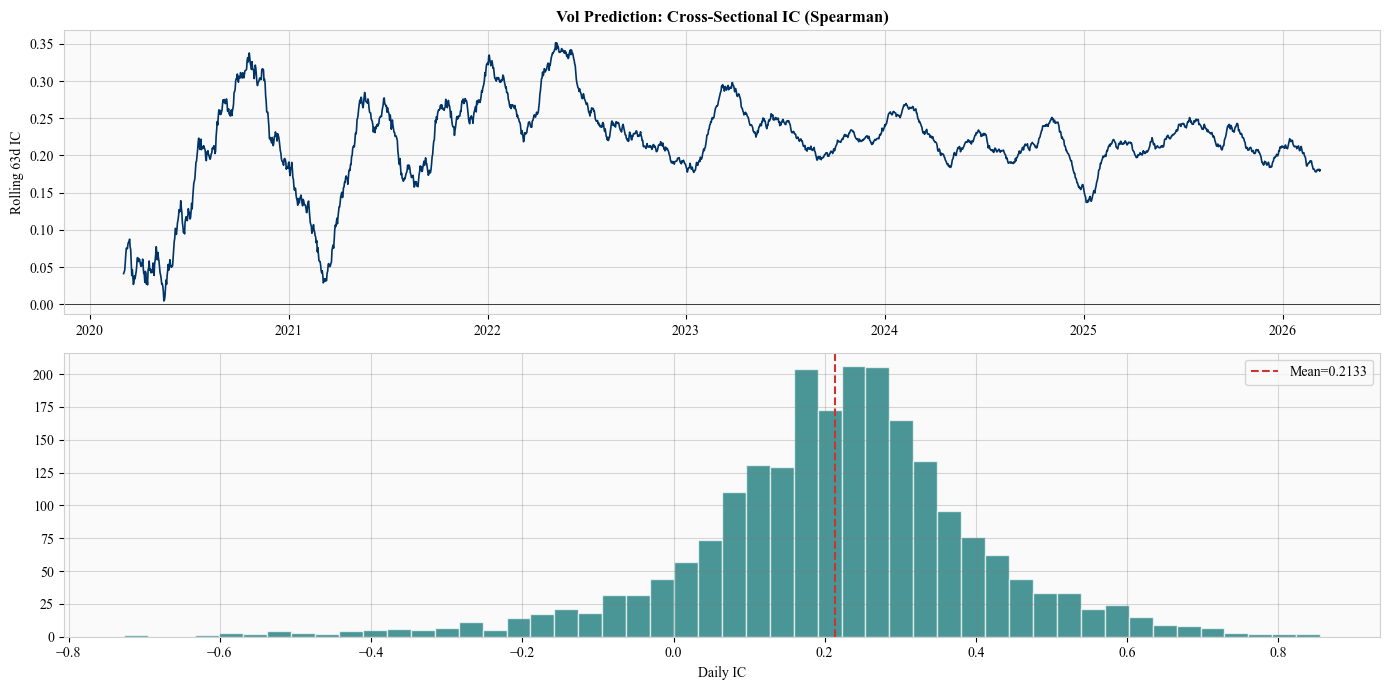

In [5]:
# Cross-sectional rank of predicted vol (higher = more expected movement)
pred_vol_rank = predicted_vol.rank(axis=1, pct=True)

# Actual realized vol rank for comparison
actual_vol = abs_ret_1d.shift(-1)  # next-day |return|
actual_vol_rank = actual_vol.rank(axis=1, pct=True)

# Cross-sectional Spearman IC: does predicted vol rank predict actual vol rank?
from scipy.stats import spearmanr

ic_values = []
for dt in test_dates:
    p = pred_vol_rank.loc[dt].dropna()
    a = actual_vol_rank.loc[dt].dropna()
    common = p.index.intersection(a.index)
    if len(common) < 5:
        continue
    rho, _ = spearmanr(p.loc[common], a.loc[common])
    ic_values.append({"ts": dt, "ic": rho})

ic_df = pd.DataFrame(ic_values).set_index("ts")

print(f"Vol Prediction IC (Spearman rank correlation):")
print(f"  Mean IC:    {ic_df['ic'].mean():.4f}")
print(f"  IC t-stat:  {ic_df['ic'].mean() / ic_df['ic'].std() * np.sqrt(len(ic_df)):.2f}")
print(f"  Hit rate:   {(ic_df['ic'] > 0).mean():.1%}")
print(f"  IC Std:     {ic_df['ic'].std():.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
ic_rolling = ic_df["ic"].rolling(63).mean()
axes[0].plot(ic_rolling.index, ic_rolling.values, color=NAVY, lw=1.2)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_ylabel("Rolling 63d IC")
axes[0].set_title("Vol Prediction: Cross-Sectional IC (Spearman)", fontweight="bold")

axes[1].hist(ic_df["ic"].values, bins=50, color=TEAL, alpha=0.7, edgecolor="white")
axes[1].axvline(ic_df["ic"].mean(), color=RED, ls="--", label=f"Mean={ic_df['ic'].mean():.4f}")
axes[1].set_xlabel("Daily IC")
axes[1].legend()
fig.tight_layout()
plt.show()

## 4 — Strategy A: Predicted Movers × Momentum

**Logic:** Each day, identify the top quintile of predicted vol ("predicted movers").  
Among those, go long names with positive recent momentum, short those with negative.  
This concentrates capital where moves are expected to be largest.

In [6]:
MOM_LOOKBACK = 21
VOL_QUINTILE = 0.80  # top 20% predicted vol

momentum = ret_w.rolling(MOM_LOOKBACK).mean()

def build_predicted_movers_weights(
    pred_rank: pd.DataFrame,
    momentum: pd.DataFrame,
    universe: pd.DataFrame,
    vol_threshold: float = VOL_QUINTILE,
) -> pd.DataFrame:
    """Long predicted movers with +mom, short those with -mom."""
    is_mover = (pred_rank >= vol_threshold) & universe
    mom_sign = momentum.apply(np.sign)

    long  = is_mover &  (mom_sign > 0)
    short = is_mover &  (mom_sign < 0)

    n_long  = long.sum(axis=1).clip(lower=1)
    n_short = short.sum(axis=1).clip(lower=1)

    w_long  = long.astype(float).div(n_long, axis=0) * 0.5
    w_short = short.astype(float).div(n_short, axis=0) * (-0.5)

    weights = (w_long + w_short).fillna(0)
    return weights

weights_a = build_predicted_movers_weights(pred_vol_rank, momentum, univ_w)

common = weights_a.columns.intersection(ret_w.columns)
bt_a = simple_backtest(weights_a[common], ret_w[common], cost_bps=COST_BPS)
eq_a = bt_a.set_index("ts")["portfolio_equity"]
m_a = compute_metrics(eq_a)
m_a["label"] = "A: Predicted Movers × Mom"
m_a["avg_turnover"] = bt_a["turnover"].mean()

print(format_metrics_table([m_a]))
print(f"\nAvg daily turnover: {m_a['avg_turnover']:.1%}")
print(f"Avg gross exposure: {bt_a['gross_exposure'].mean():.1%}")
print(f"Avg positions: long={weights_a.clip(lower=0).gt(0).sum(axis=1).mean():.1f}, "
      f"short={weights_a.clip(upper=0).lt(0).sum(axis=1).mean():.1f}")

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
A: Predicted Movers × Mom       -31.2%   41.6%    -0.69    -0.93  -97.3%  35.5%    0.73   10.56

Avg daily turnover: 49.9%
Avg gross exposure: 62.9%
Avg positions: long=10.4, short=6.2


## 5 — Strategy B: Vol Surprise Continuation

When realized vol **exceeds** predicted vol (positive surprise), something  
fundamental may have changed. Bet on continuation in the direction of the move.

In [7]:
SURPRISE_THRESHOLD = 1.5  # realized / predicted > threshold = surprise

realized_1d = abs_ret_1d
predicted_1d = predicted_vol.shift(1).clip(lower=1e-8)  # yesterday's prediction for today

vol_surprise = realized_1d / predicted_1d
is_surprise = vol_surprise > SURPRISE_THRESHOLD

ret_direction = ret_w.apply(np.sign)

def build_vol_surprise_weights(
    is_surprise: pd.DataFrame,
    ret_direction: pd.DataFrame,
    universe: pd.DataFrame,
    threshold: float = SURPRISE_THRESHOLD,
) -> pd.DataFrame:
    """After a vol surprise, bet on continuation for 1 day."""
    eligible = is_surprise & universe
    n_elig = eligible.sum(axis=1).clip(lower=1)
    w = eligible.astype(float) * ret_direction
    w = w.div(n_elig, axis=0).fillna(0)
    gross = w.abs().sum(axis=1)
    w = w.div(gross.clip(lower=1e-8), axis=0)
    return w

weights_b = build_vol_surprise_weights(is_surprise, ret_direction, univ_w)

common_b = weights_b.columns.intersection(ret_w.columns)
bt_b = simple_backtest(weights_b[common_b], ret_w[common_b], cost_bps=COST_BPS)
eq_b = bt_b.set_index("ts")["portfolio_equity"]
m_b = compute_metrics(eq_b)
m_b["label"] = "B: Vol Surprise Continuation"
m_b["avg_turnover"] = bt_b["turnover"].mean()

print(format_metrics_table([m_b]))
print(f"\nAvg daily turnover: {m_b['avg_turnover']:.1%}")
print(f"Days with any surprise: {is_surprise.any(axis=1).mean():.1%}")

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
B: Vol Surprise Continuation    -84.3%   76.1%    -2.04    -2.41 -100.0%  28.7%   -0.12   13.42

Avg daily turnover: 124.9%
Days with any surprise: 70.8%


## 6 — Strategy C: Vol Concentration Overlay

Take a standard momentum signal and **weight by predicted vol rank**.  
This doesn't change direction — it concentrates existing bets where vol is expected.

In [8]:
# Baseline: simple cross-sectional momentum (top/bottom quintile)
mom_rank = momentum.rank(axis=1, pct=True)

def build_cs_momentum_weights(mom_rank, universe, quintile=0.2):
    long = (mom_rank >= 1 - quintile) & universe
    short = (mom_rank <= quintile) & universe
    n_long = long.sum(axis=1).clip(lower=1)
    n_short = short.sum(axis=1).clip(lower=1)
    w = long.astype(float).div(n_long, axis=0) * 0.5 - short.astype(float).div(n_short, axis=0) * 0.5
    return w.fillna(0)

# Baseline momentum
w_mom_base = build_cs_momentum_weights(mom_rank, univ_w)
common_m = w_mom_base.columns.intersection(ret_w.columns)
bt_mom = simple_backtest(w_mom_base[common_m], ret_w[common_m], cost_bps=COST_BPS)
eq_mom = bt_mom.set_index("ts")["portfolio_equity"]
m_mom = compute_metrics(eq_mom)
m_mom["label"] = "Baseline: CS Momentum"
m_mom["avg_turnover"] = bt_mom["turnover"].mean()

# Vol-concentrated momentum: multiply weights by predicted vol rank
vol_multiplier = pred_vol_rank.clip(lower=0.1)
w_mom_vol = w_mom_base * vol_multiplier
# Renormalize to same gross exposure
gross = w_mom_vol.abs().sum(axis=1)
target_gross = w_mom_base.abs().sum(axis=1)
scale = target_gross / gross.clip(lower=1e-8)
w_mom_vol = w_mom_vol.mul(scale, axis=0).fillna(0)

bt_c = simple_backtest(w_mom_vol[common_m], ret_w[common_m], cost_bps=COST_BPS)
eq_c = bt_c.set_index("ts")["portfolio_equity"]
m_c = compute_metrics(eq_c)
m_c["label"] = "C: Vol-Concentrated Mom"
m_c["avg_turnover"] = bt_c["turnover"].mean()

print(format_metrics_table([m_mom, m_c]))

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
Baseline: CS Momentum           -29.8%   36.7%    -0.78    -1.09  -95.4%  43.8%    0.88   15.46
C: Vol-Concentrated Mom         -17.8%   54.0%    -0.10    -0.13  -95.1%  34.4%    2.12   38.35


---
## 7 — Combined comparison

In [9]:
# BTC benchmark
btc_eq = compute_btc_benchmark(panel)
btc_eq = btc_eq.loc[btc_eq.index >= START]
btc_m = compute_metrics(btc_eq)
btc_m["label"] = "BTC Buy & Hold"

all_m = [m_a, m_b, m_c, m_mom, btc_m]
print(format_metrics_table(all_m))

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
A: Predicted Movers × Mom       -31.2%   41.6%    -0.69    -0.93  -97.3%  35.5%    0.73   10.56
B: Vol Surprise Continuation    -84.3%   76.1%    -2.04    -2.41 -100.0%  28.7%   -0.12   13.42
C: Vol-Concentrated Mom         -17.8%   54.0%    -0.10    -0.13  -95.1%  34.4%    2.12   38.35
Baseline: CS Momentum           -29.8%   36.7%    -0.78    -1.09  -95.4%  43.8%    0.88   15.46
BTC Buy & Hold                   44.6%   62.0%     0.91     1.22  -76.7%  50.9%   -0.52   12.10


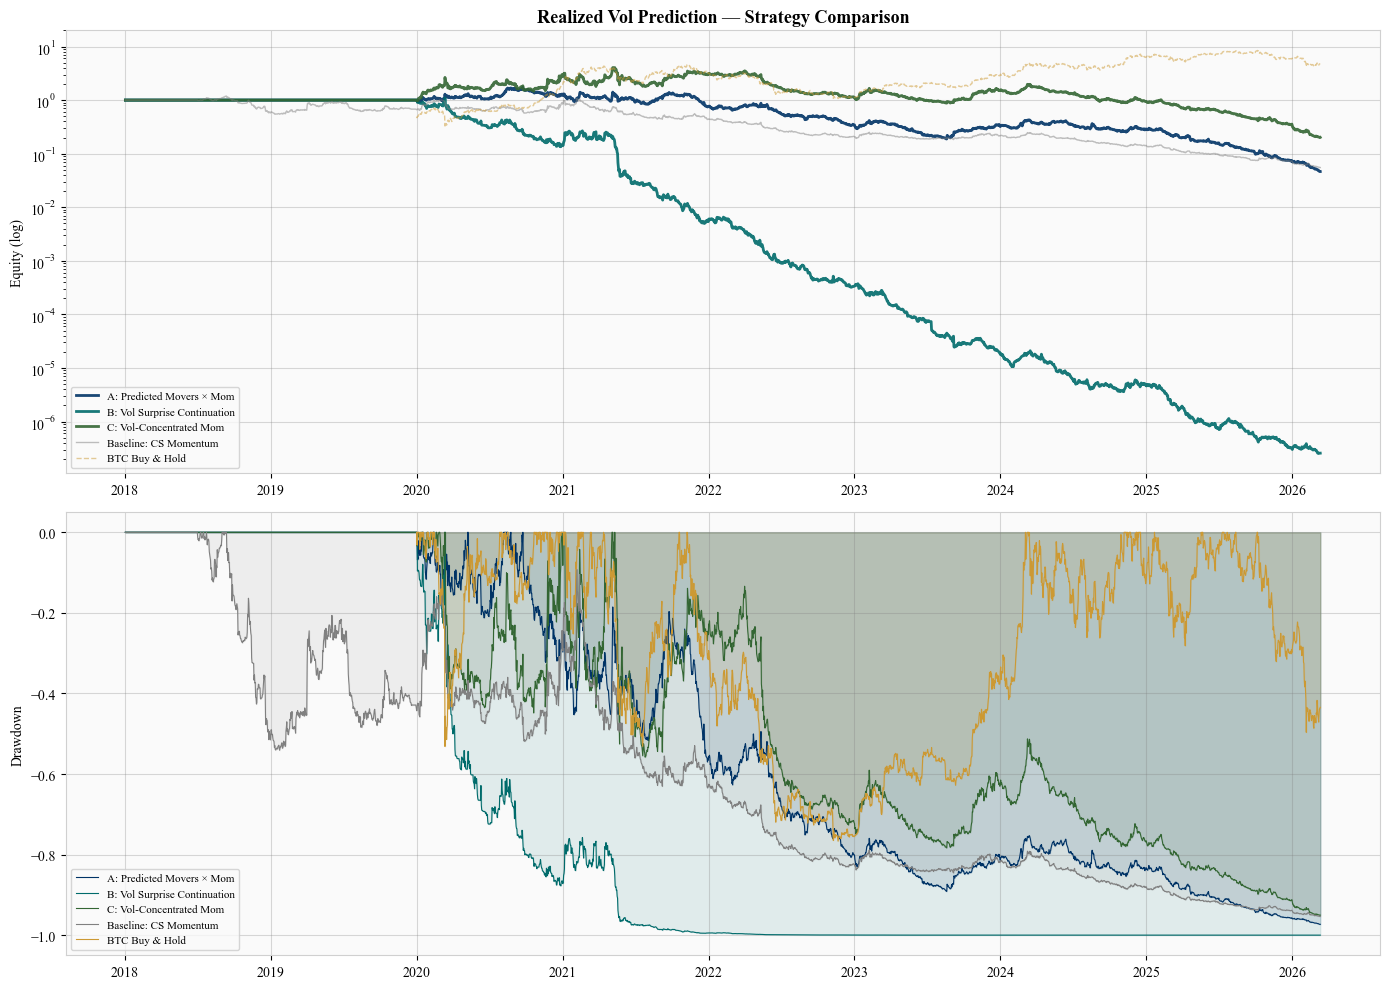

In [10]:
equities = {
    m_a["label"]: eq_a,
    m_b["label"]: eq_b,
    m_c["label"]: eq_c,
    m_mom["label"]: eq_mom,
    btc_m["label"]: btc_eq,
}
colors_list = [NAVY, TEAL, GREEN, GRAY, GOLD]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (label, eq) in enumerate(equities.items()):
    lw = 2.0 if i < 3 else 1.0
    ls = "-" if i < 4 else "--"
    axes[0].plot(eq.index, eq.values, label=label,
                 color=colors_list[i], lw=lw, ls=ls, alpha=0.9 if i < 3 else 0.5)
axes[0].set_yscale("log")
axes[0].set_ylabel("Equity (log)")
axes[0].set_title("Realized Vol Prediction — Strategy Comparison", fontweight="bold", fontsize=13)
axes[0].legend(fontsize=8)

for i, (label, eq) in enumerate(equities.items()):
    if "B&H" in label:
        continue
    dd = eq / eq.cummax() - 1
    axes[1].fill_between(dd.index, 0, dd.values, alpha=0.1, color=colors_list[i])
    axes[1].plot(dd.index, dd.values, lw=0.8, color=colors_list[i], label=label)
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=8, loc="lower left")

fig.tight_layout()
plt.show()

### Yearly Sharpe breakdown

In [11]:
print(f"{'Strategy':<30s}", end="")
for yr in range(2020, 2027):
    print(f" {yr:>7d}", end="")
print()
print("-" * 80)

for label, eq in equities.items():
    if "B&H" in label:
        continue
    ret = eq.pct_change().dropna()
    print(f"{label:<30s}", end="")
    for yr in range(2020, 2027):
        yr_ret = ret[ret.index.year == yr]
        if len(yr_ret) < 30:
            print(f"     {'—':>4s}", end="")
            continue
        mu = yr_ret.mean()
        sigma = yr_ret.std()
        sr = (mu / sigma) * np.sqrt(365) if sigma > 1e-12 else 0
        print(f" {sr:>7.2f}", end="")
    print()

Strategy                          2020    2021    2022    2023    2024    2025    2026
--------------------------------------------------------------------------------
A: Predicted Movers × Mom         0.68   -0.53   -1.59    0.12   -0.11   -3.41   -6.20
B: Vol Surprise Continuation     -1.70   -2.16   -3.04   -3.01   -1.48   -3.24   -1.42
C: Vol-Concentrated Mom           1.60    0.51   -2.42    0.85   -1.19   -2.97   -6.07
Baseline: CS Momentum             0.77   -1.14   -2.76    0.24   -1.71   -2.70   -4.96
BTC Buy & Hold                    2.25    0.98   -1.28    2.35    1.74    0.05   -1.44


### Strategy correlations

In [12]:
strat_rets = pd.DataFrame({
    k: v.pct_change() for k, v in equities.items()
}).dropna()

print("Daily return correlations:")
print(strat_rets.corr().to_string(float_format="{:.3f}".format))

Daily return correlations:
                              A: Predicted Movers × Mom  B: Vol Surprise Continuation  C: Vol-Concentrated Mom  Baseline: CS Momentum  BTC Buy & Hold
A: Predicted Movers × Mom                         1.000                         0.122                    0.656                  0.541           0.004
B: Vol Surprise Continuation                      0.122                         1.000                    0.159                  0.101          -0.066
C: Vol-Concentrated Mom                           0.656                         0.159                    1.000                  0.713           0.055
Baseline: CS Momentum                             0.541                         0.101                    0.713                  1.000           0.017
BTC Buy & Hold                                    0.004                        -0.066                    0.055                  0.017           1.000


### Momentum lookback sensitivity

In [13]:
sweep_mom = []
for mlb in [5, 10, 21, 42, 63]:
    mom_s = ret_w.rolling(mlb).mean()
    w = build_predicted_movers_weights(pred_vol_rank, mom_s, univ_w)
    cs = w.columns.intersection(ret_w.columns)
    bt = simple_backtest(w[cs], ret_w[cs], cost_bps=COST_BPS)
    if bt.empty:
        continue
    eq = bt.set_index("ts")["portfolio_equity"]
    m = compute_metrics(eq)
    m["mom_lb"] = mlb
    m["avg_turnover"] = bt["turnover"].mean()
    sweep_mom.append(m)

sweep_df = pd.DataFrame(sweep_mom)
print("Strategy A — momentum lookback sweep:")
print(sweep_df[["mom_lb", "sharpe", "cagr", "max_dd", "avg_turnover"]].to_string(
    index=False,
    float_format=lambda x: f"{x:.2f}" if abs(x) < 5 else f"{x:.1%}",
))

Strategy A — momentum lookback sweep:
 mom_lb  sharpe  cagr  max_dd  avg_turnover
      5   -0.98 -0.44   -1.00          0.65
     10   -0.44 -0.25   -0.97          0.57
     21   -0.69 -0.31   -0.97          0.50
     42   -0.98 -0.39   -0.98          0.45
     63   -0.96 -0.39   -0.98          0.44


---
## 8 — Conclusions

In [14]:
print("="*70)
print("SUMMARY")
print("="*70)
print(f"\nVol Prediction IC:  mean={ic_df['ic'].mean():.4f}, "
      f"t-stat={ic_df['ic'].mean()/ic_df['ic'].std()*np.sqrt(len(ic_df)):.1f}, "
      f"hit={((ic_df['ic']>0).mean()):.0%}")
print(f"Model R² (median):  {r2_df.median():.4f}")
print()
print(format_metrics_table(all_m))
print()

print("Key observations:")
print("  - Vol is highly predictable (R² and IC confirm)")
print("  - The question is whether vol PREDICTION adds alpha vs just using raw vol")
print("  - Compare Strategy C (vol-concentrated) vs Baseline Momentum")

if m_c["sharpe"] > m_mom["sharpe"]:
    delta = m_c["sharpe"] - m_mom["sharpe"]
    print(f"  - Vol concentration IMPROVES Sharpe by {delta:.2f}")
else:
    delta = m_mom["sharpe"] - m_c["sharpe"]
    print(f"  - Vol concentration HURTS Sharpe by {delta:.2f}")
    print(f"  - This suggests crypto vol prediction adds noise, not signal")

SUMMARY

Vol Prediction IC:  mean=0.2133, t-stat=52.8, hit=90%
Model R² (median):  -0.0275

Strategy                           CAGR      Vol   Sharpe  Sortino    MaxDD    Hit%    Skew    Kurt
---------------------------------------------------------------------------------------------------
A: Predicted Movers × Mom       -31.2%   41.6%    -0.69    -0.93  -97.3%  35.5%    0.73   10.56
B: Vol Surprise Continuation    -84.3%   76.1%    -2.04    -2.41 -100.0%  28.7%   -0.12   13.42
C: Vol-Concentrated Mom         -17.8%   54.0%    -0.10    -0.13  -95.1%  34.4%    2.12   38.35
Baseline: CS Momentum           -29.8%   36.7%    -0.78    -1.09  -95.4%  43.8%    0.88   15.46
BTC Buy & Hold                   44.6%   62.0%     0.91     1.22  -76.7%  50.9%   -0.52   12.10

Key observations:
  - Vol is highly predictable (R² and IC confirm)
  - The question is whether vol PREDICTION adds alpha vs just using raw vol
  - Compare Strategy C (vol-concentrated) vs Baseline Momentum
  - Vol concentratio